In [1]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/behaviour_detection.csv')
df1['condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/behaviour_detection.csv')
df2['condition'] = 'Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/behaviour_detection.csv')
df3['condition'] = 'Starved-Starved'


df = pd.concat([df1, df2, df3], ignore_index=True)


order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']
palette = {
    "Fed-Fed": "#4C72B0",
    "Fed-Starved": "#55A868",
    "Starved-Starved": "#C44E52",
}



/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_53284/1736026649.py:21: DtypeWarning: Columns (97,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/behaviour_detection.csv')


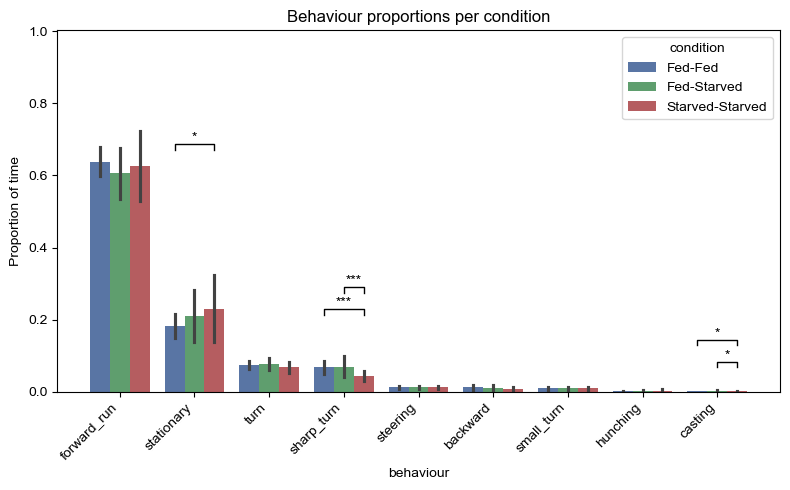

Omnibus tests


,behaviour,test,H,p,stars
3,sharp_turn,Kruskal-Wallis,25.687897,0.000003,***
8,casting,Kruskal-Wallis,9.580133,0.008312,**
1,stationary,Kruskal-Wallis,6.160950,0.045937,*
2,turn,Kruskal-Wallis,5.999441,0.049801,*
0,forward_run,Kruskal-Wallis,3.458130,0.177450,ns
5,backward,Kruskal-Wallis,2.973317,0.226127,ns
7,hunching,Kruskal-Wallis,1.608490,0.447426,ns
6,small_turn,Kruskal-Wallis,1.008422,0.603982,ns
4,steering,Kruskal-Wallis,0.054501,0.973117,ns


Pairwise tests for behaviours with significant omnibus p < 0.05, Holm-corrected within behaviour


,behaviour,condition_a,condition_b,comparison,test,U,p_raw,p_holm,stars
11,casting,Fed-Starved,Starved-Starved,Fed-Starved vs Starved-Starved,Mann-Whitney U,507.5,0.005502,0.016507,*
10,casting,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,509.5,0.012415,0.024829,*
9,casting,Fed-Fed,Fed-Starved,Fed-Fed vs Fed-Starved,Mann-Whitney U,325.0,0.650034,0.650034,ns
7,sharp_turn,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,629.0,0.000005,0.000015,***
8,sharp_turn,Fed-Starved,Starved-Starved,Fed-Starved vs Starved-Starved,Mann-Whitney U,583.0,0.000038,0.000076,***
6,sharp_turn,Fed-Fed,Fed-Starved,Fed-Fed vs Fed-Starved,Mann-Whitney U,374.0,0.688921,0.688921,ns
1,stationary,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,214.0,0.009459,0.028378,*
0,stationary,Fed-Fed,Fed-Starved,Fed-Fed vs Fed-Starved,Mann-Whitney U,277.0,0.190971,0.381941,ns
2,stationary,Fed-Starved,Starved-Starved,Fed-Starved vs Starved-Starved,Mann-Whitney U,305.0,0.418206,0.418206,ns
4,turn,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,485.0,0.037894,0.100473,ns


In [2]:
# Proportion of time, excluding digging, with stats and plot significance labels

prop_df = df[df["behaviour"].astype(str).str.lower() != "digging"].copy()

# Total non-digging frames per recording and condition.
total_frames = (
    prop_df.groupby(["file", "condition"])
    .size()
    .reset_index(name="total_frames")
)

# Frames per behaviour per recording and condition.
behaviour_frames = (
    prop_df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

behaviour_order = (
    behaviour_frames.groupby("behaviour")["n_frames"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

recordings = total_frames[["file", "condition"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(behaviour_frames, on=["file", "condition", "behaviour"], how="left")
    .merge(total_frames, on=["file", "condition"], how="left")
)
behaviour_prop["n_frames"] = behaviour_prop["n_frames"].fillna(0)
behaviour_prop = behaviour_prop[behaviour_prop["total_frames"] > 0].copy()
behaviour_prop["proportion"] = behaviour_prop["n_frames"] / behaviour_prop["total_frames"]

# Order by the final plotted value: overall mean proportion, highest to lowest.
behaviour_order = (
    behaviour_prop.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

proportion_omnibus_rows = []
proportion_pairwise_rows = []

for behaviour in behaviour_order:
    behaviour_data = behaviour_prop[behaviour_prop["behaviour"] == behaviour]
    groups = [
        behaviour_data.loc[behaviour_data["condition"] == condition, "proportion"].dropna()
        for condition in order
    ]

    if all(len(group) > 0 for group in groups):
        h_stat, p_value = kruskal(*groups)
    else:
        h_stat, p_value = np.nan, np.nan

    proportion_omnibus_rows.append({
        "behaviour": behaviour,
        "test": "Kruskal-Wallis",
        "H": h_stat,
        "p": p_value,
        "stars": p_to_stars(p_value),
    })

    if pd.notna(p_value) and p_value < 0.05:
        comparisons = []
        raw_p_values = []

        for condition_a, condition_b in combinations(order, 2):
            values_a = behaviour_data.loc[
                behaviour_data["condition"] == condition_a,
                "proportion"
            ].dropna()
            values_b = behaviour_data.loc[
                behaviour_data["condition"] == condition_b,
                "proportion"
            ].dropna()

            if len(values_a) > 0 and len(values_b) > 0:
                u_stat, pair_p = mannwhitneyu(values_a, values_b, alternative="two-sided")
            else:
                u_stat, pair_p = np.nan, np.nan

            comparisons.append((condition_a, condition_b, u_stat, pair_p))
            raw_p_values.append(pair_p)

        valid_p_values = [p for p in raw_p_values if pd.notna(p)]
        if valid_p_values:
            corrected = multipletests(valid_p_values, method="holm")[1]
            corrected_iter = iter(corrected)
        else:
            corrected_iter = iter([])

        for condition_a, condition_b, u_stat, pair_p in comparisons:
            p_holm = next(corrected_iter) if pd.notna(pair_p) else np.nan
            proportion_pairwise_rows.append({
                "behaviour": behaviour,
                "condition_a": condition_a,
                "condition_b": condition_b,
                "comparison": f"{condition_a} vs {condition_b}",
                "test": "Mann-Whitney U",
                "U": u_stat,
                "p_raw": pair_p,
                "p_holm": p_holm,
                "stars": p_to_stars(p_holm),
            })

proportion_omnibus_stats = pd.DataFrame(proportion_omnibus_rows)
proportion_pairwise_stats = pd.DataFrame(proportion_pairwise_rows)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=behaviour_prop,
    x="behaviour",
    y="proportion",
    hue="condition",
    errorbar="sd",
    palette=palette,
    hue_order=order,
    order=behaviour_order,
)

if not proportion_pairwise_stats.empty:
    significant_pairs = proportion_pairwise_stats[proportion_pairwise_stats["p_holm"] < 0.05].copy()
    x_lookup = {behaviour: i for i, behaviour in enumerate(behaviour_order)}
    hue_offsets = {
        condition: (i - (len(order) - 1) / 2) * 0.8 / len(order)
        for i, condition in enumerate(order)
    }
    y_max = behaviour_prop["proportion"].max()
    y_step = max(y_max * 0.08, 0.02)

    for behaviour, behaviour_pairs in significant_pairs.groupby("behaviour", sort=False):
        behaviour_max = behaviour_prop.loc[
            behaviour_prop["behaviour"] == behaviour,
            "proportion"
        ].max()
        for level, (_, row) in enumerate(behaviour_pairs.sort_values("p_holm").iterrows()):
            x1 = x_lookup[behaviour] + hue_offsets[row["condition_a"]]
            x2 = x_lookup[behaviour] + hue_offsets[row["condition_b"]]
            y = behaviour_max + y_step * (level + 1)
            h = y_step * 0.25
            ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1)
            ax.text((x1 + x2) / 2, y + h, row["stars"], ha="center", va="bottom", color="black")

    ax.set_ylim(0, y_max + y_step * (significant_pairs.groupby("behaviour").size().max() + 2))
else:
    plt.ylim(0, None)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of time")
plt.title("Behaviour proportions per condition")

plt.tight_layout()
plt.show()

print("Omnibus tests")
display(proportion_omnibus_stats.sort_values("p"))

print("Pairwise tests for behaviours with significant omnibus p < 0.05, Holm-corrected within behaviour")
if proportion_pairwise_stats.empty:
    display(pd.DataFrame(columns=["behaviour", "comparison", "test", "U", "p_raw", "p_holm", "stars"]))
else:
    display(proportion_pairwise_stats.sort_values(["behaviour", "p_holm"]))

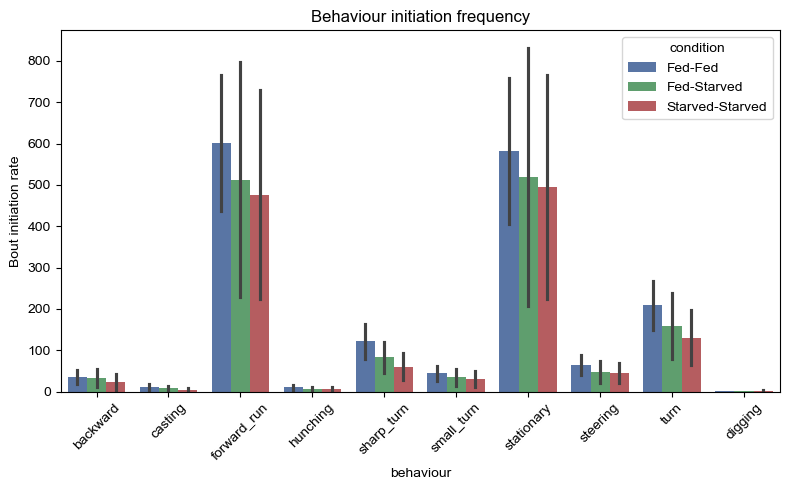

In [3]:
df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd", palette=palette, hue_order=order
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()

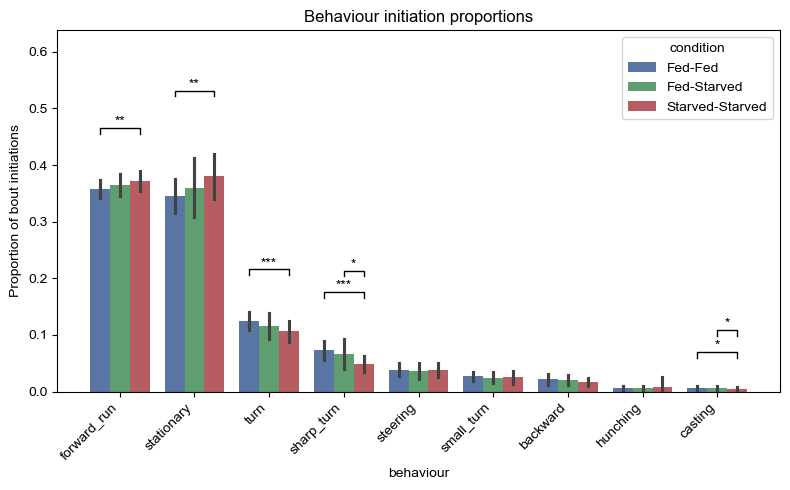

Omnibus tests


,behaviour,test,H,p,stars
3,sharp_turn,Kruskal-Wallis,20.518899,0.000035,***
1,stationary,Kruskal-Wallis,12.112768,0.002343,**
2,turn,Kruskal-Wallis,11.971700,0.002514,**
0,forward_run,Kruskal-Wallis,9.417136,0.009018,**
8,casting,Kruskal-Wallis,8.400898,0.014989,*
6,backward,Kruskal-Wallis,3.817052,0.148299,ns
7,hunching,Kruskal-Wallis,1.787590,0.409100,ns
5,small_turn,Kruskal-Wallis,0.979878,0.612664,ns
4,steering,Kruskal-Wallis,0.747317,0.688212,ns


Pairwise tests for behaviours with significant omnibus p < 0.05, Holm-corrected within behaviour


,behaviour,condition_a,condition_b,comparison,test,U,p_raw,p_holm,stars
13,casting,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,514.0,0.009940,0.029821,*
14,casting,Fed-Starved,Starved-Starved,Fed-Starved vs Starved-Starved,Mann-Whitney U,486.0,0.016701,0.033403,*
12,casting,Fed-Fed,Fed-Starved,Fed-Fed vs Fed-Starved,Mann-Whitney U,358.5,0.900882,0.900882,ns
1,forward_run,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,180.0,0.001457,0.004370,**
0,forward_run,Fed-Fed,Fed-Starved,Fed-Fed vs Fed-Starved,Mann-Whitney U,275.0,0.179176,0.325024,ns
2,forward_run,Fed-Starved,Starved-Starved,Fed-Starved vs Starved-Starved,Mann-Whitney U,272.0,0.162512,0.325024,ns
10,sharp_turn,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,633.5,0.000003,0.000010,***
11,sharp_turn,Fed-Starved,Starved-Starved,Fed-Starved vs Starved-Starved,Mann-Whitney U,502.0,0.007413,0.014826,*
9,sharp_turn,Fed-Fed,Fed-Starved,Fed-Fed vs Fed-Starved,Mann-Whitney U,423.0,0.203327,0.203327,ns
4,stationary,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,158.0,0.000366,0.001097,**


In [4]:
# Proportion of bout initiations, excluding digging, with stats and plot significance labels
# Matches the GS logic: remove digging before counting initiations and exclude track starts.

bout_df = df[df["behaviour"].astype(str).str.lower() != "digging"].copy()

bout_df = bout_df.sort_values(["file", "track_id", "frame"])
bout_df["prev_behaviour"] = bout_df.groupby(["file", "track_id"])["behaviour"].shift()
bout_df = bout_df[bout_df["prev_behaviour"].notna()].copy()
bout_df["is_initiation"] = bout_df["behaviour"] != bout_df["prev_behaviour"]

bout_counts_no_digging = (
    bout_df[bout_df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

behaviour_order = (
    bout_counts_no_digging.groupby("behaviour")["n_bouts"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

recordings = bout_counts_no_digging[["file", "condition"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

bout_prop = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(bout_counts_no_digging, on=["file", "condition", "behaviour"], how="left")
)
bout_prop["n_bouts"] = bout_prop["n_bouts"].fillna(0)
bout_prop["total_bouts"] = bout_prop.groupby(["file", "condition"])["n_bouts"].transform("sum")
bout_prop = bout_prop[bout_prop["total_bouts"] > 0].copy()
bout_prop["bout_initiation_proportion"] = bout_prop["n_bouts"] / bout_prop["total_bouts"]

# Order by the final plotted value: overall mean proportion, highest to lowest.
behaviour_order = (
    bout_prop.groupby("behaviour")["bout_initiation_proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

omnibus_rows = []
pairwise_rows = []

for behaviour in behaviour_order:
    behaviour_data = bout_prop[bout_prop["behaviour"] == behaviour]
    groups = [
        behaviour_data.loc[behaviour_data["condition"] == condition, "bout_initiation_proportion"].dropna()
        for condition in order
    ]

    if all(len(group) > 0 for group in groups):
        h_stat, p_value = kruskal(*groups)
    else:
        h_stat, p_value = np.nan, np.nan

    omnibus_rows.append({
        "behaviour": behaviour,
        "test": "Kruskal-Wallis",
        "H": h_stat,
        "p": p_value,
        "stars": p_to_stars(p_value),
    })

    if pd.notna(p_value) and p_value < 0.05:
        comparisons = []
        raw_p_values = []

        for condition_a, condition_b in combinations(order, 2):
            values_a = behaviour_data.loc[
                behaviour_data["condition"] == condition_a,
                "bout_initiation_proportion"
            ].dropna()
            values_b = behaviour_data.loc[
                behaviour_data["condition"] == condition_b,
                "bout_initiation_proportion"
            ].dropna()

            if len(values_a) > 0 and len(values_b) > 0:
                u_stat, pair_p = mannwhitneyu(values_a, values_b, alternative="two-sided")
            else:
                u_stat, pair_p = np.nan, np.nan

            comparisons.append((condition_a, condition_b, u_stat, pair_p))
            raw_p_values.append(pair_p)

        valid_p_values = [p for p in raw_p_values if pd.notna(p)]
        if valid_p_values:
            corrected = multipletests(valid_p_values, method="holm")[1]
            corrected_iter = iter(corrected)
        else:
            corrected_iter = iter([])

        for condition_a, condition_b, u_stat, pair_p in comparisons:
            p_holm = next(corrected_iter) if pd.notna(pair_p) else np.nan
            pairwise_rows.append({
                "behaviour": behaviour,
                "condition_a": condition_a,
                "condition_b": condition_b,
                "comparison": f"{condition_a} vs {condition_b}",
                "test": "Mann-Whitney U",
                "U": u_stat,
                "p_raw": pair_p,
                "p_holm": p_holm,
                "stars": p_to_stars(p_holm),
            })

omnibus_stats = pd.DataFrame(omnibus_rows)
pairwise_stats = pd.DataFrame(pairwise_rows)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=bout_prop,
    x="behaviour",
    y="bout_initiation_proportion",
    hue="condition",
    errorbar="sd",
    palette=palette,
    hue_order=order,
    order=behaviour_order,
)

if not pairwise_stats.empty:
    significant_pairs = pairwise_stats[pairwise_stats["p_holm"] < 0.05].copy()
    x_lookup = {behaviour: i for i, behaviour in enumerate(behaviour_order)}
    hue_offsets = {
        condition: (i - (len(order) - 1) / 2) * 0.8 / len(order)
        for i, condition in enumerate(order)
    }
    y_max = bout_prop["bout_initiation_proportion"].max()
    y_step = max(y_max * 0.08, 0.02)

    for behaviour, behaviour_pairs in significant_pairs.groupby("behaviour", sort=False):
        behaviour_max = bout_prop.loc[
            bout_prop["behaviour"] == behaviour,
            "bout_initiation_proportion"
        ].max()
        for level, (_, row) in enumerate(behaviour_pairs.sort_values("p_holm").iterrows()):
            x1 = x_lookup[behaviour] + hue_offsets[row["condition_a"]]
            x2 = x_lookup[behaviour] + hue_offsets[row["condition_b"]]
            y = behaviour_max + y_step * (level + 1)
            h = y_step * 0.25
            ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1)
            ax.text((x1 + x2) / 2, y + h, row["stars"], ha="center", va="bottom", color="black")

    ax.set_ylim(0, y_max + y_step * (significant_pairs.groupby("behaviour").size().max() + 2))

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of bout initiations")
plt.title("Behaviour initiation proportions")

plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/bout_initiation_proportions.pdf', format='pdf')
plt.show()

print("Omnibus tests")
display(omnibus_stats.sort_values("p"))

print("Pairwise tests for behaviours with significant omnibus p < 0.05, Holm-corrected within behaviour")
if pairwise_stats.empty:
    display(pd.DataFrame(columns=["behaviour", "comparison", "test", "U", "p_raw", "p_holm", "stars"]))
else:
    display(pairwise_stats.sort_values(["behaviour", "p_holm"]))